In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot
from sklearn.metrics import accuracy_score

In [2]:
data= pd.read_csv("binary_dataset_balanced_200.csv")
data.head()

,age,income,hours_study,experience_years,outcome
0,63,48697,6.04,16,1
1,20,32232,6.83,16,1
2,46,39571,5.85,5,0
3,52,53459,4.71,15,1
4,56,57914,1.83,8,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               200 non-null    int64  
 1   income            200 non-null    int64  
 2   hours_study       200 non-null    float64
 3   experience_years  200 non-null    int64  
 4   outcome           200 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 7.9 KB


In [4]:
x=data.drop("outcome",axis=1)
y=data["outcome"]

In [5]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=10)

scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)


In [20]:
model=keras.Sequential([
    layers.Dense(16,activation="relu",input_shape=(4,)),
    layers.Dense(8,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])

C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history=model.fit(
    xtrain,ytrain,epochs=30,batch_size=40,validation_split=0.2
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.4375 - loss: 0.7294 - val_accuracy: 0.3125 - val_loss: 0.7918
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4453 - loss: 0.7208 - val_accuracy: 0.3125 - val_loss: 0.7801
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4531 - loss: 0.7142 - val_accuracy: 0.3125 - val_loss: 0.7691
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4609 - loss: 0.7076 - val_accuracy: 0.3438 - val_loss: 0.7595
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4609 - loss: 0.7021 - val_accuracy: 0.3438 - val_loss: 0.7507
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4766 - loss: 0.6963 - val_accuracy: 0.3438 - val_loss: 0.7425
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6912 - val_accuracy: 0.3438 - val_loss: 0.7342
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5312 - loss: 0.6862 - val_accuracy: 0.3438 - val_loss: 0.7260


In [23]:
history.history

{'accuracy': [0.4375,
  0.4453125,
  0.453125,
  0.4609375,
  0.4609375,
  0.4765625,
  0.5,
  0.53125,
  0.5390625,
  0.5390625,
  0.546875,
  0.5625,
  0.5703125,
  0.5625,
  0.5859375,
  0.609375,
  0.6171875,
  0.6484375,
  0.6796875,
  0.6875,
  0.6796875,
  0.6796875,
  0.6953125,
  0.703125,
  0.703125,
  0.703125,
  0.703125,
  0.6953125,
  0.6953125,
  0.7109375],
 'loss': [0.7294228076934814,
  0.7208149433135986,
  0.714240312576294,
  0.7076379060745239,
  0.7021490335464478,
  0.6962786316871643,
  0.6911694407463074,
  0.6861822605133057,
  0.6810306310653687,
  0.6764195561408997,
  0.6719509363174438,
  0.6673707962036133,
  0.663008451461792,
  0.658927321434021,
  0.6553335785865784,
  0.6509755849838257,
  0.6470201015472412,
  0.6432073712348938,
  0.6393245458602905,
  0.6357128620147705,
  0.6322267055511475,
  0.6286309361457825,
  0.625282883644104,
  0.6218537092208862,
  0.6178702116012573,
  0.6142259240150452,
  0.6104744672775269,
  0.6066659688949585,
  0.

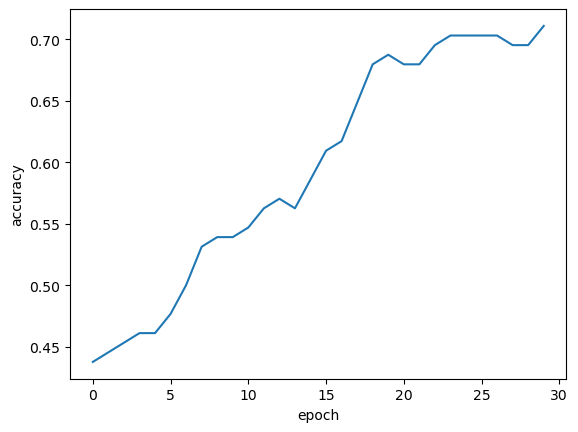

In [24]:
pyplot.plot(history.history["accuracy"])
pyplot.xlabel("epoch")
pyplot.ylabel("accuracy")
pyplot.show()

In [25]:
jj=model.evaluate(xtest,ytest)
jj

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7000 - loss: 0.5980


[0.5980294346809387, 0.699999988079071]

In [26]:
yprob=model.predict(xtest)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [27]:
ypred=(yprob>0.5).astype(int)

In [28]:
acc=accuracy_score(ytest,ypred)
acc

0.7